# Higher Quality Dataset

## Imports

In [1]:
import json
from datasets import load_dataset
from collections import Counter
import matplotlib.pyplot as plt
import statistics
import numpy as np
import re
import random
import pandas as pd


# STEP 1 - DATA LOADING

In [2]:
from datasets import load_dataset
import json

ds = load_dataset(
    "togethercomputer/RedPajama-Data-V2",
    name="default",
    partition="head_middle",
    snapshots=["2023-06"],
    languages=["en"],
    streaming=True
)

def fails_quality_filter(doc):
    qs = json.loads(doc["quality_signals"])
    word_count = qs["rps_doc_word_count"][0][2]
    if word_count < 50 or word_count > 100_000:
        return True
    mean_word_length = qs["rps_doc_mean_word_length"][0][2]
    if mean_word_length < 3 or mean_word_length > 10:
        return True
    symbol_ratio = qs["rps_doc_symbol_to_word_ratio"][0][2]
    if symbol_ratio > 0.1:
        return True
    stop_word_fraction = qs["rps_doc_stop_word_fraction"][0][2]
    if stop_word_fraction < 0.1:
        return True
    top_2gram = qs["rps_doc_frac_chars_top_2gram"][0][2]
    if top_2gram > 0.2:
        return True
    return False

dataset = []
for doc in ds["train"]:
    if not fails_quality_filter(doc):
        dataset.append(doc)
    if len(dataset) == 5000:
        break

print(f"High-quality documents collected: {len(dataset)}")


High-quality documents collected: 5000


In [3]:
language_scores = []
languages_detected = []

for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    lang_score = qs["ccnet_language_score"][0][2]
    language_scores.append(lang_score)
    meta = json.loads(doc["meta"]) if isinstance(doc["meta"], str) else doc["meta"]
    languages_detected.append(meta.get("language", "unknown"))

lang_counts = Counter(languages_detected)
print("Language distribution:")
for lang, count in lang_counts.most_common(10):
    print(f"  {lang}: {count} documents ({100 * count / len(dataset):.1f}%)")

print(f"\nAverage language confidence score: {sum(language_scores) / len(language_scores):.3f}")


Language distribution:
  en: 5000 documents (100.0%)

Average language confidence score: 0.941


# STEP 2 - BASIC EXPLORATION

Total documents: 5000
Average length:  5539 characters
Median length:   3032 characters
Shortest: 253 characters
Longest:  461577 characters

Documents under 100 chars:  0
Documents over 100k chars:  9


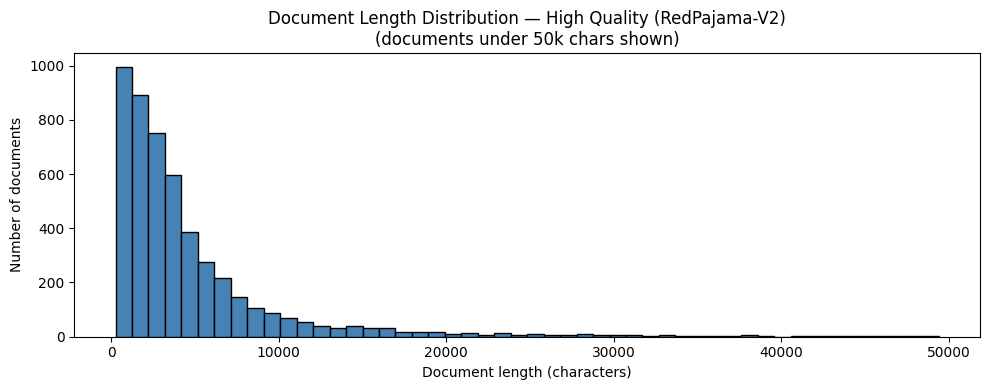

In [4]:
lengths = [len(doc["raw_content"]) for doc in dataset]

print(f"Total documents: {len(lengths)}")
print(f"Average length:  {sum(lengths)/len(lengths):.0f} characters")
print(f"Median length:   {statistics.median(lengths):.0f} characters")
print(f"Shortest: {min(lengths)} characters")
print(f"Longest:  {max(lengths)} characters")
print(f"\nDocuments under 100 chars:  {sum(1 for l in lengths if l < 100)}")
print(f"Documents over 100k chars:  {sum(1 for l in lengths if l > 100_000)}")

filtered_lengths = [l for l in lengths if l < 50_000]
plt.figure(figsize=(10, 4))
plt.hist(filtered_lengths, bins=50, color="steelblue", edgecolor="black")
plt.title("Document Length Distribution — High Quality (RedPajama-V2)\n(documents under 50k chars shown)")
plt.xlabel("Document length (characters)")
plt.ylabel("Number of documents")
plt.tight_layout()
plt.show()


In [5]:
print(f"Keys: {dataset[0].keys()}")
print()
print("--- Example document ---")
print(dataset[0]["raw_content"][:500])


Keys: dict_keys(['raw_content', 'doc_id', 'meta', 'quality_signals'])

--- Example document ---
AMICUS ANTHOLOGIES, PART ONE (1965-1972)
February 23, 2017 Alfred Eaker Leave a comment
With Dr. Terror’s House of Horrors (1965, directed by Freddie Francis and written by Milton Subotsky) Amicus Productions (spearheaded by Subotsky and Max Rosenberg, who previously produced for Hammer and was a cousin to Doris Wishman) established itself as a vital competitor to Hammer Studios. Rather than imitating Hammer’s modernization of Gothic classics, Amicus developed its own niche with omnibus films. T


In [6]:
qs = json.loads(dataset[0]["quality_signals"])

print("Quality signals for document 0:")
for key, value in qs.items():
    print(f"  {key}: {value}")


Quality signals for document 0:
  ccnet_length: [[0, 10040, 10040.0]]
  ccnet_original_length: [[0, 10040, 32101.0]]
  ccnet_nlines: [[0, 10040, 28.0]]
  ccnet_original_nlines: [[0, 10040, 284.0]]
  ccnet_language_score: [[0, 10040, 0.94]]
  ccnet_perplexity: [[0, 10040, 304.6]]
  ccnet_bucket: [[0, 10040, 0.0]]
  rps_doc_curly_bracket: [[0, 10040, 0.0]]
  rps_doc_ldnoobw_words: [[0, 10040, 1.0]]
  rps_doc_lorem_ipsum: [[0, 10040, 0.0]]
  rps_doc_stop_word_fraction: [[0, 10040, 0.35632184]]
  rps_doc_ut1_blacklist: [[0, 10040, None]]
  rps_doc_frac_chars_dupe_10grams: [[0, 10040, 0.0]]
  rps_doc_frac_chars_dupe_5grams: [[0, 10040, 0.02528991]]
  rps_doc_frac_chars_dupe_6grams: [[0, 10040, 0.01505058]]
  rps_doc_frac_chars_dupe_7grams: [[0, 10040, 0.00888231]]
  rps_doc_frac_chars_dupe_8grams: [[0, 10040, 0.0]]
  rps_doc_frac_chars_dupe_9grams: [[0, 10040, 0.0]]
  rps_doc_frac_chars_top_2gram: [[0, 10040, 0.00740192]]
  rps_doc_frac_chars_top_3gram: [[0, 10040, 0.00592154]]
  rps_doc_fr

Documents that pass all Gopher rules are expected to have:
- word_count between 50 and 100,000
- mean_word_length between 3 and 10
- stop_word_fraction above 0.1 (natural fluent text)
- symbol_to_word_ratio below 0.1
- top_2gram fraction below 0.2 (low repetitiveness)

Comparing these values with the low-quality dataset will reveal the impact of the Gopher filtering pipeline described in Section 5.1.


# STEP3 - LEXICAL ANALYSIS

## TTR

Average TTR: 0.546
Median TTR:  0.541
Min TTR:     0.100
Max TTR:     0.920


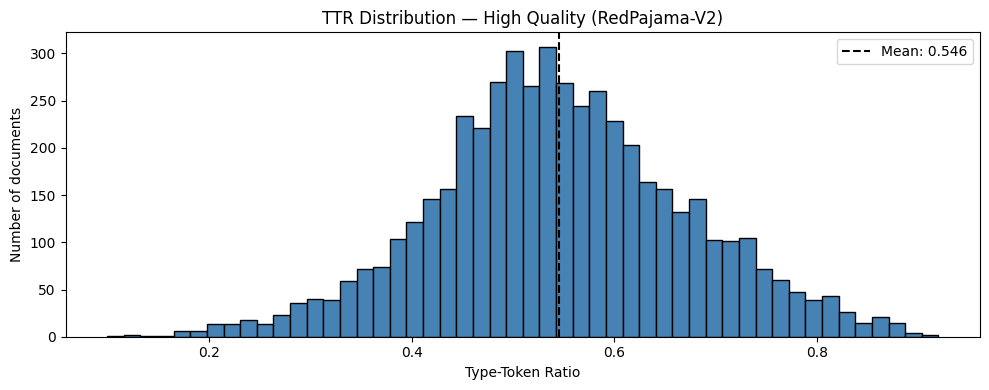

In [7]:
ttr_scores = []

for doc in dataset:
    words = doc["raw_content"].lower().split()
    if len(words) == 0:
        continue
    ttr = len(set(words)) / len(words)
    ttr_scores.append(ttr)

print(f"Average TTR: {np.mean(ttr_scores):.3f}")
print(f"Median TTR:  {np.median(ttr_scores):.3f}")
print(f"Min TTR:     {min(ttr_scores):.3f}")
print(f"Max TTR:     {max(ttr_scores):.3f}")

plt.figure(figsize=(10, 4))
plt.hist(ttr_scores, bins=50, color="steelblue", edgecolor="black")
plt.title("TTR Distribution — High Quality (RedPajama-V2)")
plt.xlabel("Type-Token Ratio")
plt.ylabel("Number of documents")
plt.axvline(np.mean(ttr_scores), color="black", linestyle="--", label=f"Mean: {np.mean(ttr_scores):.3f}")
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
lengths = [len(doc["raw_content"].split()) for doc in dataset]
correlation = np.corrcoef(lengths, ttr_scores)[0, 1]
print(f"Correlation between document length and TTR: {correlation:.3f}")


Correlation between document length and TTR: -0.442


In [9]:
buckets = {"very short (0-50 words)": [],
           "short (50-200 words)": [],
           "medium (200-500 words)": [],
           "long (500+ words)": []}

for length, ttr in zip(lengths, ttr_scores):
    if length < 50:
        buckets["very short (0-50 words)"].append(ttr)
    elif length < 200:
        buckets["short (50-200 words)"].append(ttr)
    elif length < 500:
        buckets["medium (200-500 words)"].append(ttr)
    else:
        buckets["long (500+ words)"].append(ttr)

for bucket, ttrs in buckets.items():
    if ttrs:
        print(f"{bucket}: {len(ttrs)} docs, avg TTR = {np.mean(ttrs):.3f}")


short (50-200 words): 998 docs, avg TTR = 0.707
medium (200-500 words): 1499 docs, avg TTR = 0.583
long (500+ words): 2503 docs, avg TTR = 0.459


In [10]:
all_words = []
for doc in dataset:
    words = doc["raw_content"].lower().split()
    all_words.extend(words)

word_counts = Counter(all_words)

print(f"Total tokens:       {len(all_words)}")
print(f"Unique tokens:      {len(word_counts)}")
print(f"Global TTR:         {len(word_counts)/len(all_words):.3f}")
print(f"\nTop 20 most frequent words:")
for word, count in word_counts.most_common(20):
    print(f"  '{word}': {count}")


Total tokens:       4592269
Unique tokens:      251017
Global TTR:         0.055

Top 20 most frequent words:
  'the': 253285
  'of': 134898
  'and': 130737
  'to': 126973
  'a': 97664
  'in': 89074
  'is': 54241
  'that': 49001
  'for': 45692
  'on': 32048
  'with': 30549
  'you': 28763
  'as': 28546
  'it': 28012
  'are': 26795
  'i': 26055
  'be': 25413
  'this': 23848
  'was': 23261
  'by': 21710


## Zipf's law

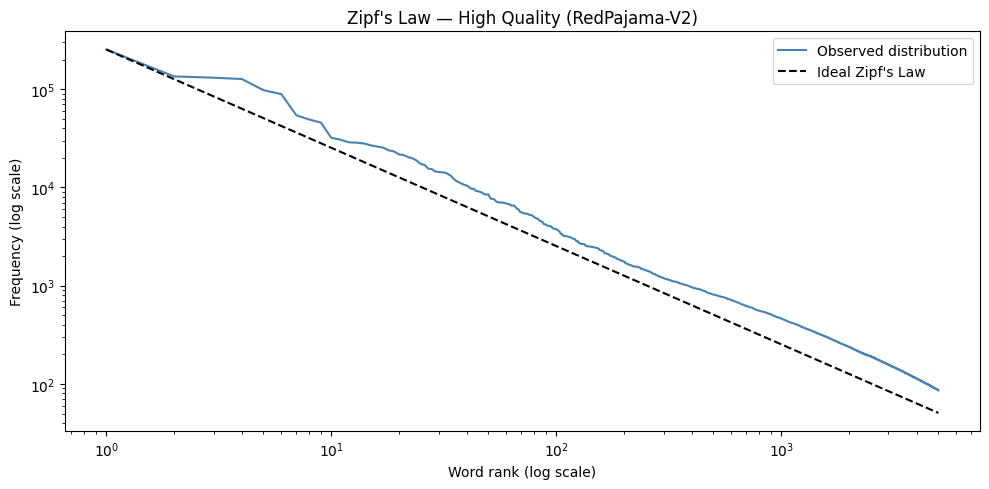

In [11]:
frequencies = sorted(word_counts.values(), reverse=True)
ranks = range(1, len(frequencies) + 1)

top_n = 5000
plt.figure(figsize=(10, 5))
plt.loglog(list(ranks)[:top_n], frequencies[:top_n],
           color="steelblue", label="Observed distribution")

ideal_zipf = [frequencies[0] / r for r in ranks[:top_n]]
plt.loglog(list(ranks)[:top_n], ideal_zipf,
           color="black", linestyle="--", label="Ideal Zipf's Law")

plt.title("Zipf's Law — High Quality (RedPajama-V2)")
plt.xlabel("Word rank (log scale)")
plt.ylabel("Frequency (log scale)")
plt.legend()
plt.tight_layout()
plt.show()


Average unigram entropy:                  4.962
Average word count:                       915.5
Median word count:                        499.0


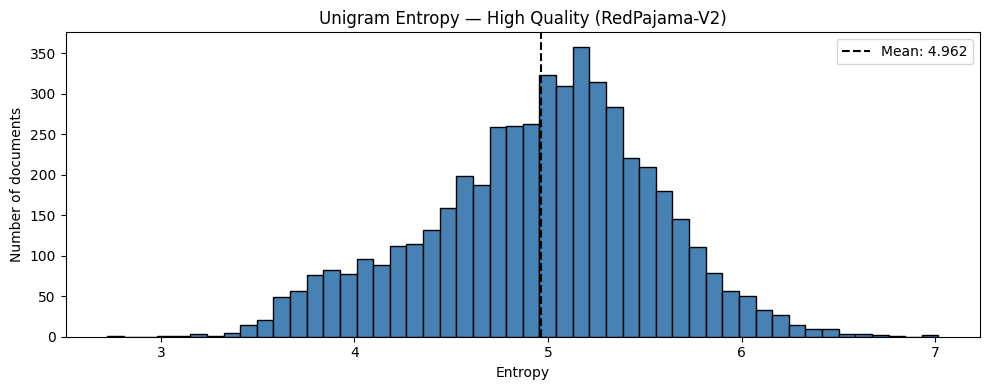

In [12]:
unigram_entropies = []
word_counts_qs = []

for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    unigram_entropies.append(qs["rps_doc_unigram_entropy"][0][2])
    word_counts_qs.append(qs["rps_doc_word_count"][0][2])

print(f"Average unigram entropy:                  {np.mean(unigram_entropies):.3f}")
print(f"Average word count:                       {np.mean(word_counts_qs):.1f}")
print(f"Median word count:                        {np.median(word_counts_qs):.1f}")

plt.figure(figsize=(10, 4))
plt.hist(unigram_entropies, bins=50, color="steelblue", edgecolor="black")
plt.title("Unigram Entropy — High Quality (RedPajama-V2)")
plt.xlabel("Entropy")
plt.ylabel("Number of documents")
plt.axvline(np.mean(unigram_entropies), color="black", linestyle="--",
            label=f"Mean: {np.mean(unigram_entropies):.3f}")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
one_word_docs = [doc for doc in dataset if len(doc["raw_content"].split()) == 1]
print(f"Documents with only one word: {len(one_word_docs)}")
if one_word_docs:
    print("\nExamples:")
    for doc in one_word_docs[:5]:
        qs = json.loads(doc["quality_signals"])
        entropy = qs["rps_doc_unigram_entropy"][0][2]
        print(f"  '{doc['raw_content'][:50]}' → entropy: {entropy}")


Documents with only one word: 0


# STEP4 - Noise Detection

## HTML Tags

In [14]:
html_tag_pattern = re.compile(r'<[^>]+>')
nbsp_pattern = re.compile(r'&nbsp;')
html_entity_pattern = re.compile(r'&[a-z]+;')

html_counts = []
nbsp_counts = []
entity_counts = []

for doc in dataset:
    text = doc["raw_content"]
    html_counts.append(len(html_tag_pattern.findall(text)))
    nbsp_counts.append(len(nbsp_pattern.findall(text)))
    entity_counts.append(len(html_entity_pattern.findall(text)))

print(f"Documents with HTML tags:     {sum(1 for c in html_counts if c > 0)} ({100*sum(1 for c in html_counts if c > 0)/len(dataset):.1f}%)")
print(f"Documents with &nbsp;:        {sum(1 for c in nbsp_counts if c > 0)} ({100*sum(1 for c in nbsp_counts if c > 0)/len(dataset):.1f}%)")
print(f"Documents with HTML entities: {sum(1 for c in entity_counts if c > 0)} ({100*sum(1 for c in entity_counts if c > 0)/len(dataset):.1f}%)")
print(f"\nAverage HTML tags per document:     {sum(html_counts)/len(html_counts):.2f}")
print(f"Average &nbsp; per document:        {sum(nbsp_counts)/len(nbsp_counts):.2f}")
print(f"Average HTML entities per document: {sum(entity_counts)/len(entity_counts):.2f}")

found = False
for doc in dataset:
    if html_tag_pattern.search(doc["raw_content"]):
        print(f"\n--- Example document with HTML tags ---")
        print(doc["raw_content"][:500])
        found = True
        break
if not found:
    print("\nNo documents with HTML tags found.")


Documents with HTML tags:     50 (1.0%)
Documents with &nbsp;:        5 (0.1%)
Documents with HTML entities: 8 (0.2%)

Average HTML tags per document:     0.04
Average &nbsp; per document:        0.01
Average HTML entities per document: 0.01

--- Example document with HTML tags ---
« Remember, Remember, to Read Stephen Spender »
Remember, Remember, to Read Stephen Spender
Over at her eponymous weblog, poet and writer Carol Peters has posted a lengthy excerpt from Stephen Spender's Poetry Since 1939 (London: Longmans, Green & Co., 1946). This short booklet is one of a series of British Council pamphlets on the Arts in Britain, published just after World War II, covering such subjects as ballet, films, music, painting, drama, and prose. Henry Reed wrote the volume for The No


## Boilerplate tags

Average symbol-to-word ratio:      0.002
Average non-alphabetical fraction: 0.172
Documents with curly brackets:     45 (0.9%)
Documents with JavaScript:         14 (0.3%)


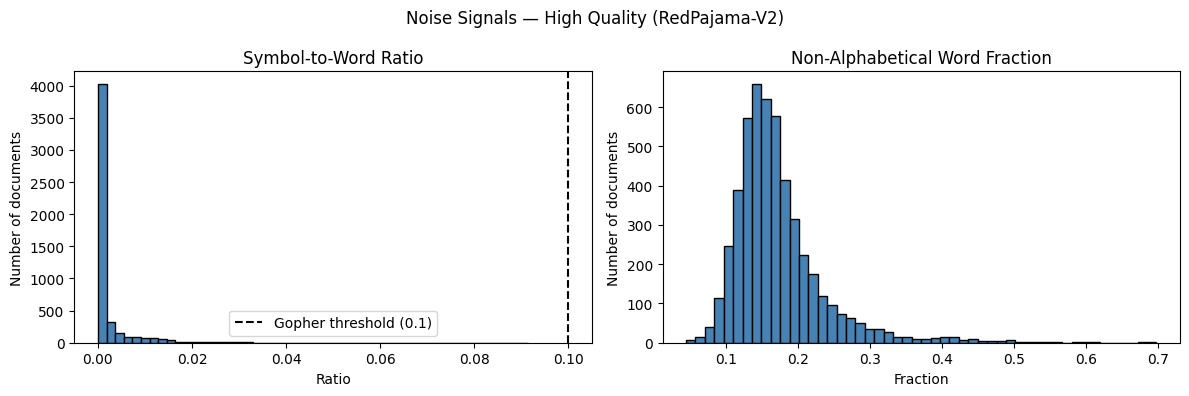

In [15]:
symbol_ratios = []
no_alph_fractions = []
curly_bracket_ratios = []
javascript_counts = []

for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    symbol_ratios.append(qs["rps_doc_symbol_to_word_ratio"][0][2])
    no_alph_fractions.append(qs["rps_doc_frac_no_alph_words"][0][2])
    curly_bracket_ratios.append(qs["rps_doc_curly_bracket"][0][2])
    js = sum(line[2] for line in qs["rps_lines_javascript_counts"])
    javascript_counts.append(js)

print(f"Average symbol-to-word ratio:      {np.mean(symbol_ratios):.3f}")
print(f"Average non-alphabetical fraction: {np.mean(no_alph_fractions):.3f}")
print(f"Documents with curly brackets:     {sum(1 for c in curly_bracket_ratios if c > 0)} ({100*sum(1 for c in curly_bracket_ratios if c > 0)/len(dataset):.1f}%)")
print(f"Documents with JavaScript:         {sum(1 for c in javascript_counts if c > 0)} ({100*sum(1 for c in javascript_counts if c > 0)/len(dataset):.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(symbol_ratios, bins=50, color="steelblue", edgecolor="black")
axes[0].set_title("Symbol-to-Word Ratio")
axes[0].set_xlabel("Ratio")
axes[0].set_ylabel("Number of documents")
axes[0].axvline(0.1, color="black", linestyle="--", label="Gopher threshold (0.1)")
axes[0].legend()

axes[1].hist(no_alph_fractions, bins=50, color="steelblue", edgecolor="black")
axes[1].set_title("Non-Alphabetical Word Fraction")
axes[1].set_xlabel("Fraction")
axes[1].set_ylabel("Number of documents")

plt.suptitle("Noise Signals — High Quality (RedPajama-V2)")
plt.tight_layout()
plt.show()


In [16]:
boilerplate_patterns = {
    "lorem ipsum": re.compile(r'lorem ipsum', re.IGNORECASE),
    "cookie notice": re.compile(r'cookie(s)?(\s+\w+)?\s+(policy|notice|consent)', re.IGNORECASE),
    "all rights reserved": re.compile(r'all rights reserved', re.IGNORECASE),
    "privacy policy": re.compile(r'privacy policy', re.IGNORECASE),
    "terms of service": re.compile(r'terms of (service|use)', re.IGNORECASE),
    "navigation menu": re.compile(r'(home\s*\|\s*about|home\s*\|\s*contact|menu\s*\|\s*home)', re.IGNORECASE),
}

boilerplate_counts = {key: 0 for key in boilerplate_patterns}

for doc in dataset:
    text = doc["raw_content"]
    for name, pattern in boilerplate_patterns.items():
        if pattern.search(text):
            boilerplate_counts[name] += 1

print("Boilerplate pattern detection:")
for pattern, count in sorted(boilerplate_counts.items(), key=lambda x: -x[1]):
    print(f"  {pattern}: {count} documents ({100*count/len(dataset):.1f}%)")


Boilerplate pattern detection:
  all rights reserved: 112 documents (2.2%)
  privacy policy: 78 documents (1.6%)
  terms of service: 49 documents (1.0%)
  cookie notice: 7 documents (0.1%)
  lorem ipsum: 5 documents (0.1%)
  navigation menu: 0 documents (0.0%)


## N-Grams

Documents with dupe 5-grams  > 0.1: 912 (18.2%)
Documents with dupe 10-grams > 0.1: 335 (6.7%)
Documents with top 2-gram    > 0.2: 0 (0.0%)

Average dupe 5-gram fraction:  0.061
Average dupe 10-gram fraction: 0.025


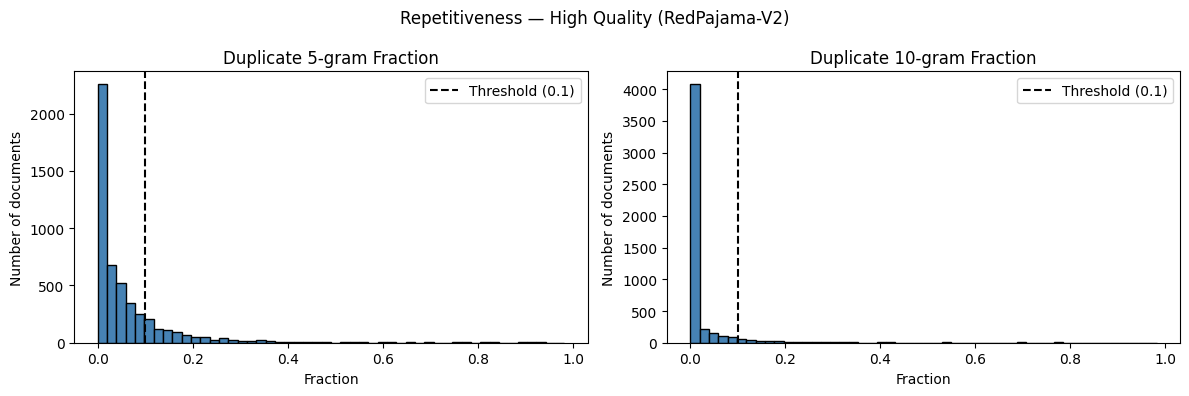

In [17]:
dupe_5gram = []
dupe_10gram = []
top_2gram = []

for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    dupe_5gram.append(qs["rps_doc_frac_chars_dupe_5grams"][0][2])
    dupe_10gram.append(qs["rps_doc_frac_chars_dupe_10grams"][0][2])
    top_2gram.append(qs["rps_doc_frac_chars_top_2gram"][0][2])

print(f"Documents with dupe 5-grams  > 0.1: {sum(1 for x in dupe_5gram if x > 0.1)} ({100*sum(1 for x in dupe_5gram if x > 0.1)/len(dataset):.1f}%)")
print(f"Documents with dupe 10-grams > 0.1: {sum(1 for x in dupe_10gram if x > 0.1)} ({100*sum(1 for x in dupe_10gram if x > 0.1)/len(dataset):.1f}%)")
print(f"Documents with top 2-gram    > 0.2: {sum(1 for x in top_2gram if x > 0.2)} ({100*sum(1 for x in top_2gram if x > 0.2)/len(dataset):.1f}%)")
print(f"\nAverage dupe 5-gram fraction:  {np.mean(dupe_5gram):.3f}")
print(f"Average dupe 10-gram fraction: {np.mean(dupe_10gram):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dupe_5gram, bins=50, color="steelblue", edgecolor="black")
axes[0].set_title("Duplicate 5-gram Fraction")
axes[0].set_xlabel("Fraction")
axes[0].set_ylabel("Number of documents")
axes[0].axvline(0.1, color="black", linestyle="--", label="Threshold (0.1)")
axes[0].legend()

axes[1].hist(dupe_10gram, bins=50, color="steelblue", edgecolor="black")
axes[1].set_title("Duplicate 10-gram Fraction")
axes[1].set_xlabel("Fraction")
axes[1].set_ylabel("Number of documents")
axes[1].axvline(0.1, color="black", linestyle="--", label="Threshold (0.1)")
axes[1].legend()

plt.suptitle("Repetitiveness — High Quality (RedPajama-V2)")
plt.tight_layout()
plt.show()


# STEP5 - Deduplication

## Duplicates

In [18]:
duplicate_flags = []
for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    duplicate_flags.append(qs["is_duplicate"])

total_duplicates = sum(duplicate_flags)
print(f"Total documents:    {len(dataset)}")
print(f"Exact duplicates:   {total_duplicates} ({100*total_duplicates/len(dataset):.1f}%)")
print(f"Unique documents:   {len(dataset) - total_duplicates} ({100*(len(dataset)-total_duplicates)/len(dataset):.1f}%)")

for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    if qs["is_duplicate"]:
        print(f"\n--- Example duplicate document ---")
        print(doc["raw_content"][:300])
        break


Total documents:    5000
Exact duplicates:   344 (6.9%)
Unique documents:   4656 (93.1%)

--- Example duplicate document ---
What our clients say about our service.
Thanks for the great Job! (L.C.)
TI loved working with Bud and Norman. They were so thorough and explained everything so well, both verbally and in the written report. I was able to look back at the detailed report and refer to pictures and descriptions when s


## Jaccard similarity

Pre-calculating n-grams for 5000 documents...
Starting all-pairs comparison (12.5M pairs)...
Comparison complete in 198.59 seconds.
------------------------------
Total pairs compared: 12497500
Average Jaccard similarity: 0.000020
Near-duplicate pairs (> 0.5): 251
Near-duplicate pairs (> 0.8): 1


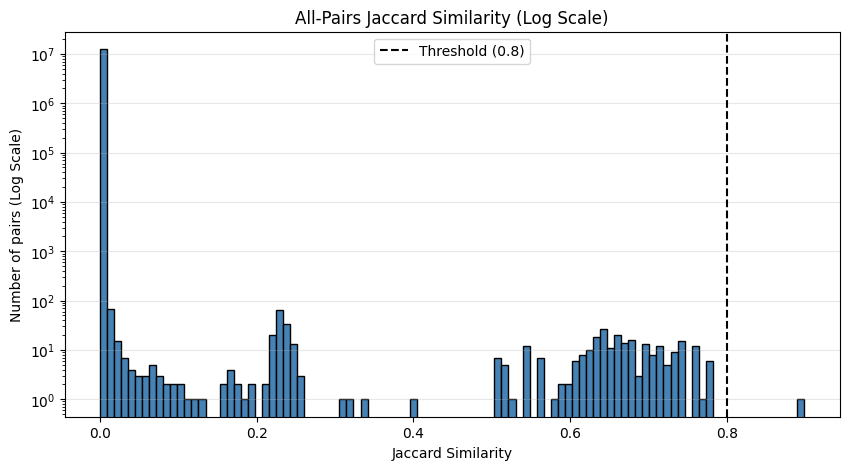

In [19]:
import time

def get_ngrams(text, n=5):
    words = text.lower().split()
    if len(words) < n:
        return set()
    return set(zip(*[words[i:] for i in range(n)]))

print(f"Pre-calculating n-grams for {len(dataset)} documents...")
start_time = time.time()
all_ngram_sets = [get_ngrams(doc["raw_content"], n=5) for doc in dataset]

jaccard_scores = []
near_duplicate_pairs = []
threshold_50 = 0.5
threshold_80 = 0.8

print("Starting all-pairs comparison (12.5M pairs)...")
num_docs = len(all_ngram_sets)

for i in range(num_docs):
    set_i = all_ngram_sets[i]
    if not set_i:
        continue

    for j in range(i + 1, num_docs):
        set_j = all_ngram_sets[j]

        intersection_len = len(set_i & set_j)

        if intersection_len == 0:
            jaccard_scores.append(0.0)
            continue

        union_len = len(set_i | set_j)
        score = intersection_len / union_len
        jaccard_scores.append(score)

        if score > threshold_50:
            near_duplicate_pairs.append((i, j, score))

end_time = time.time()
print(f"Comparison complete in {end_time - start_time:.2f} seconds.")

avg_sim = np.mean(jaccard_scores) if jaccard_scores else 0
count_80 = sum(1 for _, _, s in near_duplicate_pairs if s > 0.8)

print("-" * 30)
print(f"Total pairs compared: {len(jaccard_scores)}")
print(f"Average Jaccard similarity: {avg_sim:.6f}")
print(f"Near-duplicate pairs (> 0.5): {len(near_duplicate_pairs)}")
print(f"Near-duplicate pairs (> 0.8): {count_80}")

plt.figure(figsize=(10, 5))
plt.hist(jaccard_scores, bins=100, color="steelblue", edgecolor="black", log=True)
plt.title("All-Pairs Jaccard Similarity (Log Scale)")
plt.xlabel("Jaccard Similarity")
plt.ylabel("Number of pairs (Log Scale)")
plt.axvline(0.8, color="black", linestyle="--", label="Threshold (0.8)")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


In [20]:
top_3_pairs = sorted(near_duplicate_pairs, key=lambda x: x[2], reverse=True)[:3]

print("\n" + "="*50)
print(f"TOP 3 MOST SIMILAR PAIRS (Found {len(near_duplicate_pairs)} total matches > 0.5)")
print("="*50 + "\n")

if not top_3_pairs:
    print("No pairs found with similarity > 0.5.")
else:
    for rank, (idx1, idx2, score) in enumerate(top_3_pairs, 1):
        print(f"RANK {rank} | Jaccard Score: {score:.4f}")
        print("-" * 30)
        text1 = dataset[idx1]["raw_content"]
        text2 = dataset[idx2]["raw_content"]
        print(f"Document {idx1}: {text1[:300]}...")
        print(f"\nDocument {idx2}: {text2[:300]}...")
        print("\n" + "*"*50 + "\n")

exact_matches = [p for p in near_duplicate_pairs if p[2] >= 0.99]
print(f"Number of exact verbatim duplicates found: {len(exact_matches)}")



TOP 3 MOST SIMILAR PAIRS (Found 251 total matches > 0.5)

RANK 1 | Jaccard Score: 0.8990
------------------------------
Document 1715: By accessing “South Park Studios Forums” (hereinafter “we”, “us”, “our”, “South Park Studios Forums”, “https://forums.southpark.cc.com/forum”), you agree to be legally bound by the following terms. If you do not agree to be legally bound by all of the following terms then please do not access and/or...

Document 4798: By accessing “South Park Studios Forums” (hereinafter “we”, “us”, “our”, “South Park Studios Forums”, “https://southpark.cc.com/forum”), you agree to be legally bound by the following terms. If you do not agree to be legally bound by all of the following terms then please do not access and/or use “S...

**************************************************

RANK 2 | Jaccard Score: 0.7791
------------------------------
Document 3035: Transmission - Privacy policy
This policy explains in detail how “Transmission” along with its affiliated comp

Total Flags Analyzed: 344
------------------------------
Average Word Count: 877.9
Median Word Count:  430.0
Documents with < 5 words: 0

--- SAMPLE OF FLAGGED DUPLICATES ---
   word_count                                               text
0         602  What our clients say about our service.\nThank...
1         311  Updaty posty thingy\nSooo....\nChainmaille was...
2         256  Demonstration of a mobile unit for hybrid ener...
3        1284  Alvin Ailey American Dance Theatre is Reborn i...
4         139  Heathcare For Humanity\nBolivia / Paraguay\nLa...
5         424  Discover the certification\nCertified websites...
6        2570  MOIS History and Achievements\nMOIS History\nM...
7         352  Want to chat? We’d love to hear from you!\nGet...
8         447  Other Reference Guides (PDF)\nTo view referenc...
9         132  You are at:Home»Posts Tagged "sea world san an...


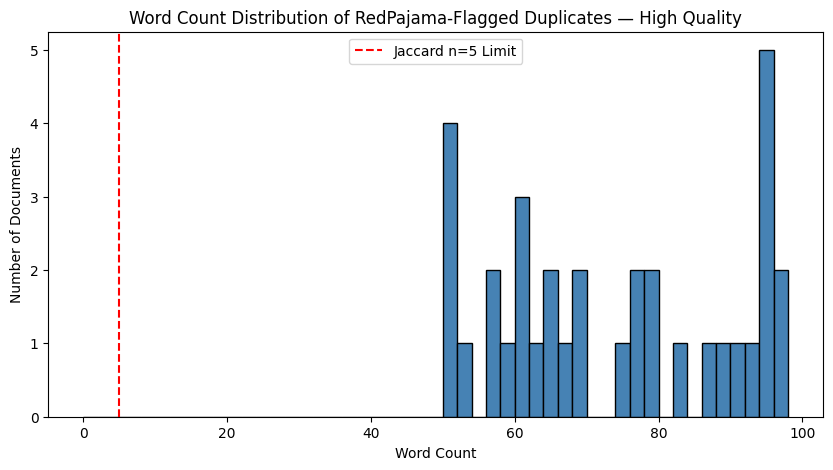

In [21]:
duplicates = [doc for doc in dataset if json.loads(doc["quality_signals"]).get("is_duplicate")]

duplicate_data = []
for doc in duplicates:
    text = doc["raw_content"]
    word_count = len(text.split())
    duplicate_data.append({
        "text": text[:100],
        "word_count": word_count,
        "is_jaccard_invisible": word_count < 5
    })

df_dupes = pd.DataFrame(duplicate_data)

print(f"Total Flags Analyzed: {len(df_dupes)}")
print("-" * 30)
print(f"Average Word Count: {df_dupes['word_count'].mean():.1f}")
print(f"Median Word Count:  {df_dupes['word_count'].median()}")
print(f"Documents with < 5 words: {df_dupes['is_jaccard_invisible'].sum()}")

print("\n--- SAMPLE OF FLAGGED DUPLICATES ---")
print(df_dupes[['word_count', 'text']].head(10))

plt.figure(figsize=(10, 5))
plt.hist(df_dupes['word_count'], bins=range(0, 100, 2), color="steelblue", edgecolor="black")
plt.axvline(5, color="red", linestyle="--", label="Jaccard n=5 Limit")
plt.title("Word Count Distribution of RedPajama-Flagged Duplicates — High Quality")
plt.xlabel("Word Count")
plt.ylabel("Number of Documents")
plt.legend()
plt.show()


## MinHash

In [22]:
from datasketch import MinHash, MinHashLSH

num_perm = 128
threshold = 0.8
n_gram_size = 5

def get_5gram_minhash(text, n=5, num_perm=128):
    m = MinHash(num_perm=num_perm)
    words = text.lower().split()
    if len(words) < n:
        return m

    for i in range(len(words) - n + 1):
        shingle = " ".join(words[i : i + n])
        m.update(shingle.encode('utf8'))
    return m

lsh = MinHashLSH(threshold=threshold, num_perm=num_perm)
minhashes = []

print(f"Generating 5-gram MinHashes for {len(dataset)} documents...")
for i, doc in enumerate(dataset):
    m = get_5gram_minhash(doc["raw_content"], n=n_gram_size, num_perm=num_perm)
    minhashes.append(m)

    if len(doc["raw_content"].split()) >= n_gram_size:
        lsh.insert(f"doc_{i}", m)

near_duplicate_counts = []
for i, m in enumerate(minhashes):
    results = lsh.query(m)
    near_duplicate_counts.append(len(results) - 1)

total_with_duplicates = sum(1 for c in near_duplicate_counts if c > 0)
print("-" * 30)
print(f"Docs with at least one 5-gram duplicate (>0.8): {total_with_duplicates}")
print(f"Max duplicates for one doc: {max(near_duplicate_counts)}")

if total_with_duplicates > 0:
    max_idx = np.argmax(near_duplicate_counts)
    print(f"\n--- Representative 5-gram Duplicate (Index {max_idx}) ---")
    print(dataset[max_idx]["raw_content"][:300])


Generating 5-gram MinHashes for 5000 documents...
------------------------------
Docs with at least one 5-gram duplicate (>0.8): 8
Max duplicates for one doc: 1

--- Representative 5-gram Duplicate (Index 374) ---
Subsonic Forum - Registration
By accessing “Subsonic Forum” (hereinafter “we”, “us”, “our”, “Subsonic Forum”, “https://forum.subsonic.org/forum”), you agree to be legally bound by the following terms. If you do not agree to be legally bound by all of the following terms then please do not access and


# STEP6 - Quality Signal Analysis

## Perplexity

--- Detailed Perplexity Breakdown ---
Repetitive/Bot (<50)     :     7 docs (0.1%)
High Quality (50-100)    :    33 docs (0.7%)
Good Web (100-150)       :   134 docs (2.7%)
Informal (150-200)       :   403 docs (8.1%)
Noisy Web (200-300)      :  2637 docs (52.7%)
Low Quality (300+)       :  1786 docs (35.7%)


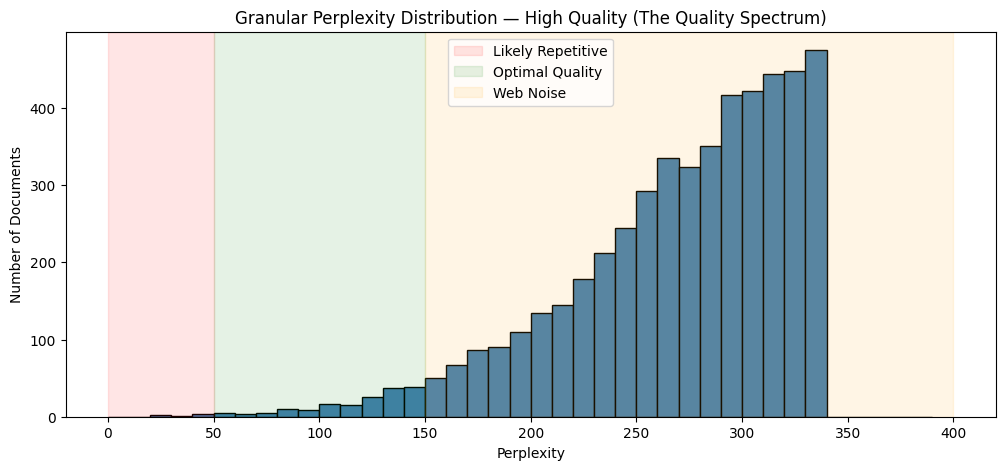


--- Samples of 'Repetitive' Documents (Perplexity < 50) ---
P=32.3 | Content: Bishop Creek, CA
Bishop Creek is a large stream in Inyo County, California. It is the largest tributary of the Owens River, with runoff at an average ...
P=45.0 | Content: Top Rated DWI Criminal Defense Attorney & Defense Attorney In Southeast Houston, TX
The Professional DWI And DUI Attorney In Southeast Houston, Texas
...
P=40.7 | Content: Minnesota Twins Review
http://twinsbaseball.com/
More Official MLB Team Websites
1. Arizona Diamondbacks
The Arizona Diamondbacks are a Major League B...


In [23]:
perplexities = []
for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    perplexities.append(qs["ccnet_perplexity"][0][2])

bins = [0, 50, 100, 150, 200, 300, 500]
labels = ['Repetitive/Bot (<50)', 'High Quality (50-100)', 'Good Web (100-150)',
          'Informal (150-200)', 'Noisy Web (200-300)', 'Low Quality (300+)']

p_series = pd.Series(perplexities)
categories = pd.cut(p_series, bins=bins, labels=labels)
counts = categories.value_counts().sort_index()

print("--- Detailed Perplexity Breakdown ---")
for label, count in counts.items():
    percentage = (count / len(perplexities)) * 100
    print(f"{label:25}: {count:5} docs ({percentage:.1f}%)")

plt.figure(figsize=(12, 5))
plt.hist(perplexities, bins=range(0, 400, 10), color="steelblue", edgecolor="black")

plt.axvspan(0, 50, color='red', alpha=0.1, label='Likely Repetitive')
plt.axvspan(50, 150, color='green', alpha=0.1, label='Optimal Quality')
plt.axvspan(150, 400, color='orange', alpha=0.1, label='Web Noise')

plt.title("Granular Perplexity Distribution — High Quality (The Quality Spectrum)")
plt.xlabel("Perplexity")
plt.ylabel("Number of Documents")
plt.legend()
plt.show()

low_p_indices = [i for i, p in enumerate(perplexities) if p < 50]
if low_p_indices:
    print("\n--- Samples of 'Repetitive' Documents (Perplexity < 50) ---")
    for idx in low_p_indices[:3]:
        print(f"P={perplexities[idx]:.1f} | Content: {dataset[idx]['raw_content'][:150]}...")


## ML-based classifiers

Average PALM score:             0.3496
Average WikiRef score:          0.3252
Average Wikipedia importance:   -177.672

Documents with PALM score > 0.1: 3166 (63.3%)


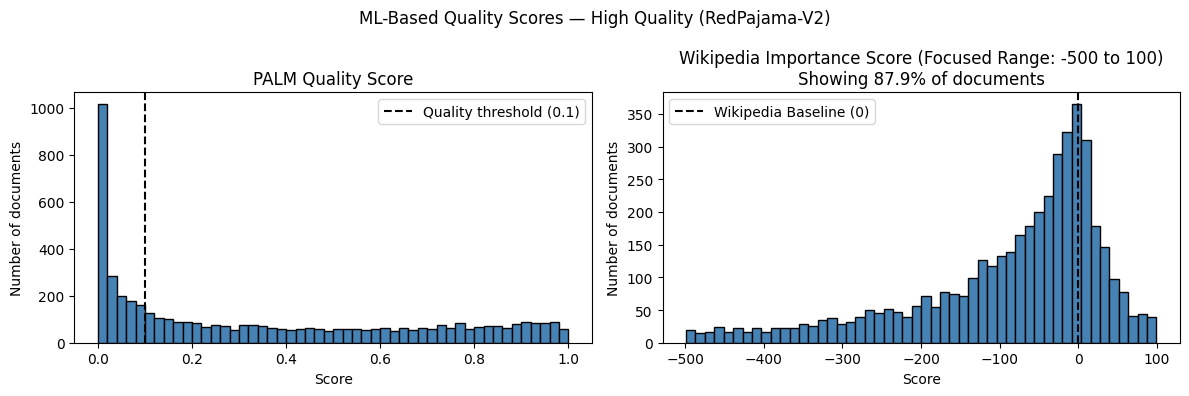

Docs above 0 (Encyclopedic): 1249
Docs below -100 (Deep Noise): 1891


In [24]:
palm_scores = []
wikiref_scores = []
wikipedia_importance = []

for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    palm = qs["rps_doc_ml_palm_score"][0][2]
    wikiref = qs["rps_doc_ml_wikiref_score"][0][2]
    wiki_imp = qs["rps_doc_wikipedia_importance"][0][2]
    if palm is not None:
        palm_scores.append(palm)
    if wikiref is not None:
        wikiref_scores.append(wikiref)
    if wiki_imp is not None:
        wikipedia_importance.append(wiki_imp)

print(f"Average PALM score:             {np.mean(palm_scores):.4f}")
print(f"Average WikiRef score:          {np.mean(wikiref_scores):.4f}")
print(f"Average Wikipedia importance:   {np.mean(wikipedia_importance):.3f}")
print(f"\nDocuments with PALM score > 0.1: {sum(1 for s in palm_scores if s > 0.1)} ({100*sum(1 for s in palm_scores if s > 0.1)/len(palm_scores):.1f}%)")

focused_wiki_imp = [s for s in wikipedia_importance if -500 <= s <= 100]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(palm_scores, bins=50, color="steelblue", edgecolor="black")
axes[0].axvline(0.1, color="black", linestyle="--", label="Quality threshold (0.1)")
axes[0].set_title("PALM Quality Score")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Number of documents")
axes[0].legend()

axes[1].hist(focused_wiki_imp, bins=50, color="steelblue", edgecolor="black")
axes[1].axvline(0, color="black", linestyle="--", label="Wikipedia Baseline (0)")
percentage_shown = 100 * len(focused_wiki_imp) / len(wikipedia_importance)
axes[1].set_title(f"Wikipedia Importance Score (Focused Range: -500 to 100)\n"
          f"Showing {percentage_shown:.1f}% of documents")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Number of documents")
axes[1].legend()

plt.suptitle("ML-Based Quality Scores — High Quality (RedPajama-V2)")
plt.tight_layout()
plt.show()

print(f"Docs above 0 (Encyclopedic): {sum(1 for s in wikipedia_importance if s > 0)}")
print(f"Docs below -100 (Deep Noise): {sum(1 for s in wikipedia_importance if s < -100)}")


## Overall quality

In [25]:
stop_word_fractions = []
mean_word_lengths = []
no_alph_fractions = []

for doc in dataset:
    qs = json.loads(doc["quality_signals"])
    stop_word_fractions.append(qs["rps_doc_stop_word_fraction"][0][2])
    mean_word_lengths.append(qs["rps_doc_mean_word_length"][0][2])
    no_alph_fractions.append(qs["rps_doc_frac_no_alph_words"][0][2])

print("=" * 50)
print("QUALITY SIGNAL SUMMARY — HIGH QUALITY DATASET")
print("=" * 50)
print(f"{'Metric':<35} {'Mean':>8} {'Median':>8}")
print("-" * 50)
print(f"{'CCNet Perplexity':<35} {np.mean(perplexities):>8.1f} {np.median(perplexities):>8.1f}")
print(f"{'Stop-word fraction':<35} {np.mean(stop_word_fractions):>8.3f} {np.median(stop_word_fractions):>8.3f}")
print(f"{'Mean word length':<35} {np.mean(mean_word_lengths):>8.3f} {np.median(mean_word_lengths):>8.3f}")
print(f"{'Non-alphabetical fraction':<35} {np.mean(no_alph_fractions):>8.3f} {np.median(no_alph_fractions):>8.3f}")
print(f"{'Unigram entropy':<35} {np.mean(unigram_entropies):>8.3f} {np.median(unigram_entropies):>8.3f}")
print(f"{'PALM score':<35} {np.mean(palm_scores):>8.4f} {np.median(palm_scores) if palm_scores else 0:>8.4f}")
print(f"{'Duplicate fraction (exact)':<35} {total_duplicates/len(dataset):>8.3f} {'N/A':>8}")
print("=" * 50)


QUALITY SIGNAL SUMMARY — HIGH QUALITY DATASET
Metric                                  Mean   Median
--------------------------------------------------
CCNet Perplexity                       270.0    281.7
Stop-word fraction                     0.371    0.380
Mean word length                       4.956    4.914
Non-alphabetical fraction              0.172    0.159
Unigram entropy                        4.962    5.019
PALM score                            0.3496   0.2419
Duplicate fraction (exact)             0.069      N/A
